## Similarity vs. Globality Anaysis
Here we analyze the dependance of the similarity metric on globality 

In [1]:
import os
# change to platonic-rep root directory
os.chdir(r'c:\Users\user\OneDrive - Technion\Documents\GitHub\platonic-rep')

In [ ]:
import torch
K = torch.randn(4,4)
tril_indices = torch.tril_indices(K.shape[0], K.shape[1], offset=-1)

: 

In [10]:
import numpy as np  
import matplotlib.pyplot as plt
import utils 
from tasks import get_models

import pandas as pd
import seaborn as sns

sim_params = {
    'modelset': 'val',
    'dataset': 'minhuh\\prh',
    'subset': 'wit_1024',
    'modality_x': 'vision',
    'modality_y': 'vision',
    'pool_x': 'cls',
    'pool_y': 'cls',
    'prompt_x': False,
    'prompt_y': False,
    'metric': 'mutual_knn',
    'sweep_len': 10,
}
# sim_params = {
#     'modelset': 'val',
#     'dataset': 'minhuh\\prh',
#     'subset': 'wit_1024',
#     'modality_x': 'language',
#     'modality_y': 'language',
#     'pool_x': 'avg',
#     'pool_y': 'avg',
#     'prompt_x': False,
#     'prompt_y': False,
#     'metric': 'mutual_knn',
#     'sweep_len': 10,
# }
fontsize = 16
results_dir = os.path.join('results', 'alignment')
load_path = utils.to_alignment_filename(
            results_dir, sim_params['dataset'], sim_params['modelset'],
            sim_params['modality_x'], sim_params['pool_x'], sim_params['prompt_x'],
            sim_params['modality_y'], sim_params['pool_y'], sim_params['prompt_y'],
            sim_params['metric'], sim_params['sweep_len']
    )
data = np.load(load_path, allow_pickle=True).item()
figure_path = f'post_processing/figures/{sim_params["modelset"]}_{sim_params["subset"]}/{sim_params["metric"]}/{sim_params["modality_x"]}_vs_{sim_params["modality_y"]}'
os.makedirs(figure_path, exist_ok=True)

In [11]:
n_models = data['scores'].shape[0]
llm_models, lvm_models = get_models(sim_params['modelset'], modality='all')
model_names_x = llm_models if sim_params['modality_x'] == "language" else lvm_models
model_names_y = llm_models if sim_params['modality_y'] == "language" else lvm_models

In [ ]:
print(model_names_x)
print(model_names_y)

['vit_tiny_patch16_224.augreg_in21k', 'vit_small_patch16_224.augreg_in21k', 'vit_base_patch16_224.augreg_in21k', 'vit_large_patch16_224.augreg_in21k', 'vit_base_patch16_224.mae', 'vit_large_patch16_224.mae', 'vit_huge_patch14_224.mae', 'vit_small_patch14_dinov2.lvd142m', 'vit_base_patch14_dinov2.lvd142m', 'vit_large_patch14_dinov2.lvd142m', 'vit_giant_patch14_dinov2.lvd142m', 'vit_base_patch16_clip_224.laion2b', 'vit_large_patch14_clip_224.laion2b', 'vit_huge_patch14_clip_224.laion2b', 'vit_base_patch16_clip_224.laion2b_ft_in12k', 'vit_large_patch14_clip_224.laion2b_ft_in12k', 'vit_huge_patch14_clip_224.laion2b_ft_in12k']
['vit_tiny_patch16_224.augreg_in21k', 'vit_small_patch16_224.augreg_in21k', 'vit_base_patch16_224.augreg_in21k', 'vit_large_patch16_224.augreg_in21k', 'vit_base_patch16_224.mae', 'vit_large_patch16_224.mae', 'vit_huge_patch14_224.mae', 'vit_small_patch14_dinov2.lvd142m', 'vit_base_patch14_dinov2.lvd142m', 'vit_large_patch14_dinov2.lvd142m', 'vit_giant_patch14_dinov2.l

In [25]:
model_names_map = {
    # vision models
    'vit_tiny_patch16_224.augreg_in21k': 'AugReg-tiny',
    'vit_small_patch16_224.augreg_in21k': 'AugReg-small',
    'vit_base_patch16_224.augreg_in21k': 'AugReg-base',
    'vit_large_patch16_224.augreg_in21k': 'AugReg-large',
    'vit_base_patch16_224.mae': 'MAE-base',
    'vit_large_patch16_224.mae': 'MAE-large',
    'vit_huge_patch14_224.mae': 'MAE-huge',
    'vit_small_patch14_dinov2.lvd142m': 'DINOv2-small',
    'vit_base_patch14_dinov2.lvd142m': 'DINOv2-base',
    'vit_large_patch14_dinov2.lvd142m': 'DINOv2-large',
    'vit_giant_patch14_dinov2.lvd142m': 'DINOv2-giant',
    'vit_base_patch16_clip_224.laion2b': 'CLIP-base',
    'vit_large_patch14_clip_224.laion2b': 'CLIP-large',
    'vit_huge_patch14_clip_224.laion2b': 'CLIP-huge',
    'vit_base_patch16_clip_224.laion2b_ft_in12k': 'CLIP-base-ft',
    'vit_large_patch14_clip_224.laion2b_ft_in12k': 'CLIP-large-ft',
    'vit_huge_patch14_clip_224.laion2b_ft_in12k': 'CLIP-huge-ft'
}

In [ ]:
# plot alignment vs. topk values for models in model list
vision_model_families = ['augreg', 'mae', 'dinov2', 'clip']
language_model_families = ['fill families here']


In [26]:
def plot_similarity_globality(
        data, 
        model_names_x: list[str], 
        model_names_y: list[str],
        model_family_x: str, 
        model_family_y: str, 
        figure_path: str,
        fontsize=16):
    """
    Plot similarity vs. globality for models in specified families.
    """
    
    sweep_vec = data['param_vec']
    param_name = data['param_name']
    same_family = model_family_x == model_family_y
    # filter models by family if model name conatins the family string
    model_list_x = [m for m in model_names_x if model_family_x in m]
    model_list_y = [m for m in model_names_y if model_family_y in m]
    plt.figure(figsize=(10,6))
    model_pairs = []
    for i, model_x in enumerate(model_list_x):
        model_x_idx = model_names_x.index(model_x)
    for j, model_y in enumerate(model_list_y):
        model_y_idx = model_names_y.index(model_y)
        if same_family and i == j:
            continue
        if (model_y, model_x) in model_pairs:
            continue
        model_pairs.append((model_x, model_y))
        alignment_scores = data['scores'][model_x_idx, model_y_idx, :]
        label = f"{model_names_map.get(model_x, model_x)} vs. {model_names_map.get(model_y, model_y)}"
        plt.plot(sweep_vec, alignment_scores, marker='o', label=label)

    plt.xlabel(f'Globality[{param_name}]', fontsize=fontsize)
    plt.ylabel(f'{sim_params["metric"]} score', fontsize=fontsize)
    plt.xticks(fontsize=fontsize-2)
    plt.yticks(fontsize=fontsize-2)
    plt.grid(True)
    plt.legend(fontsize=fontsize)
    plt.savefig(f'{figure_path}/sim_globality_{model_family_x}_vs_{model_family_y}.png', dpi=300)

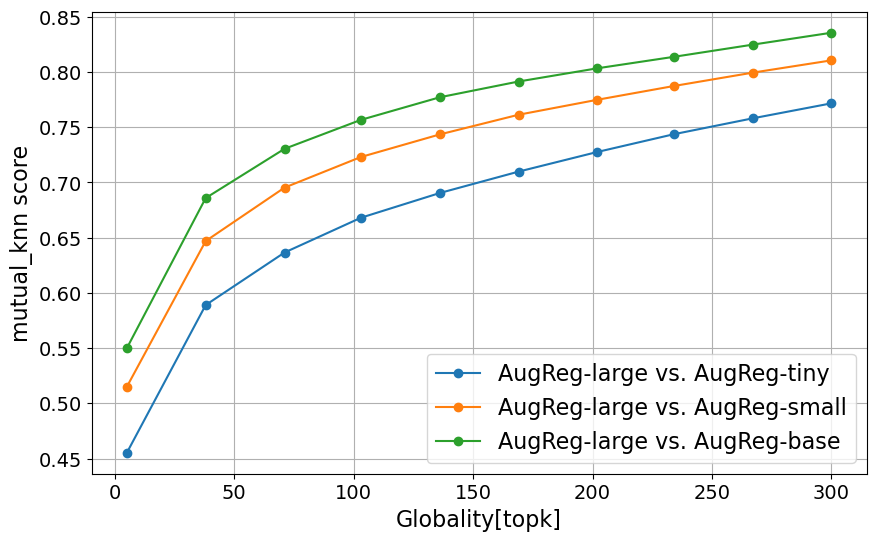

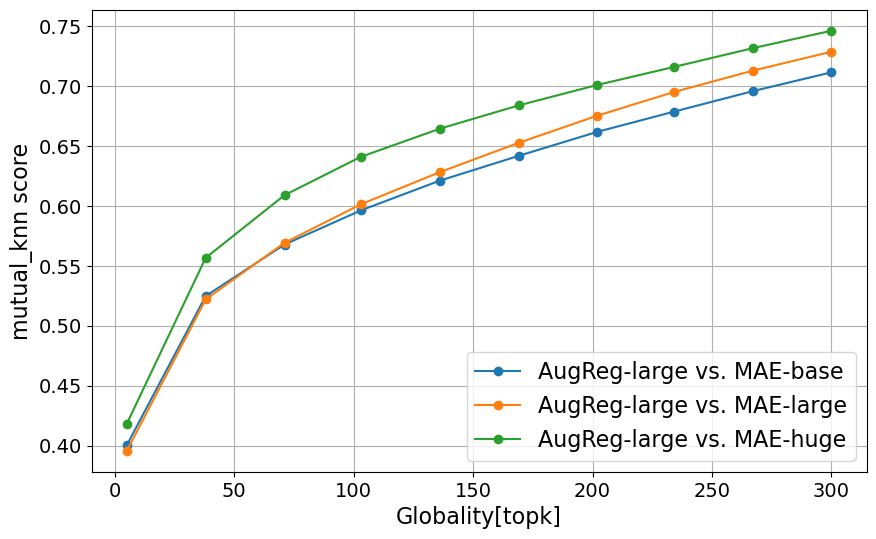

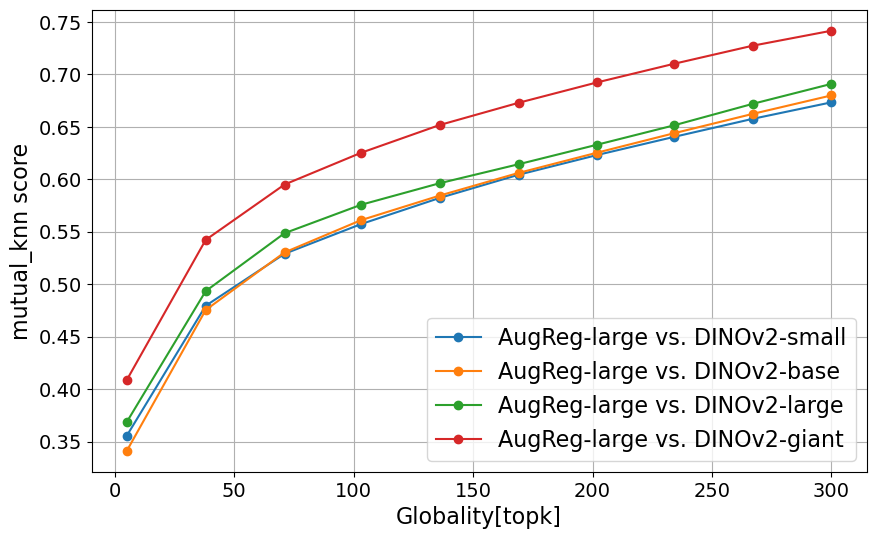

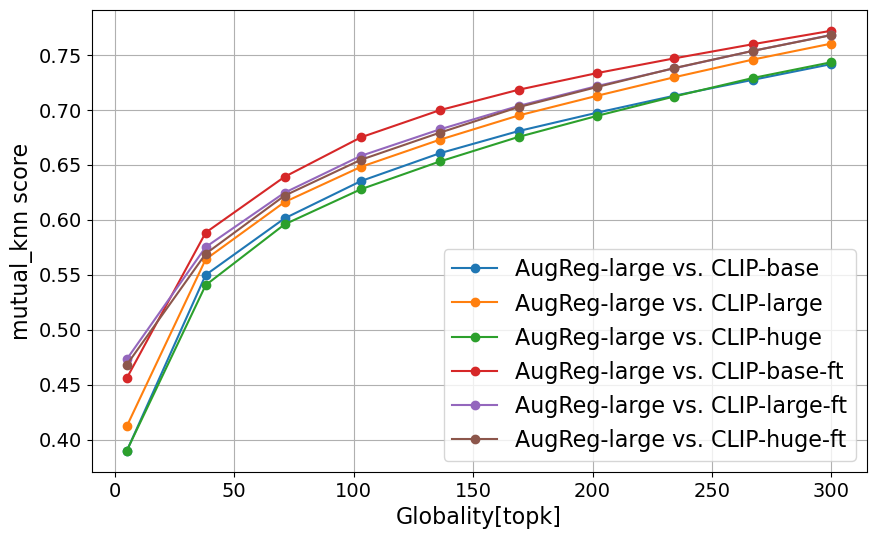

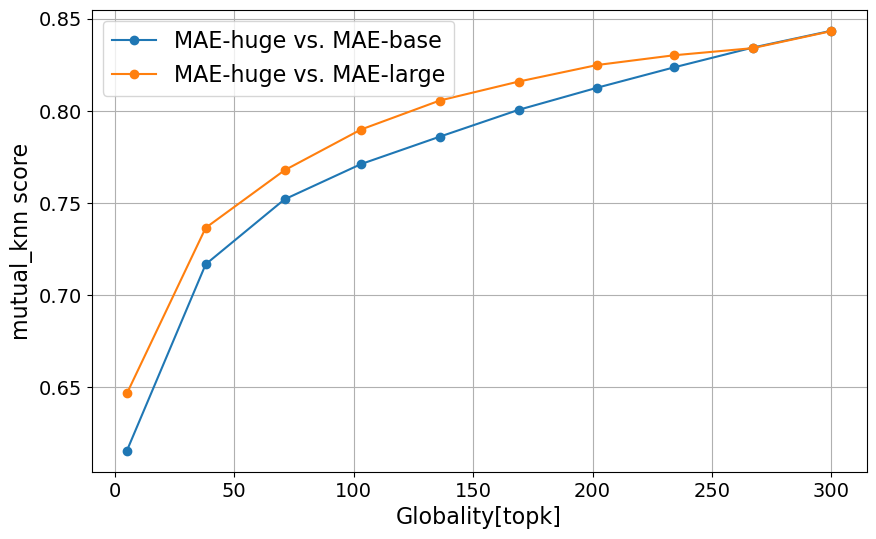

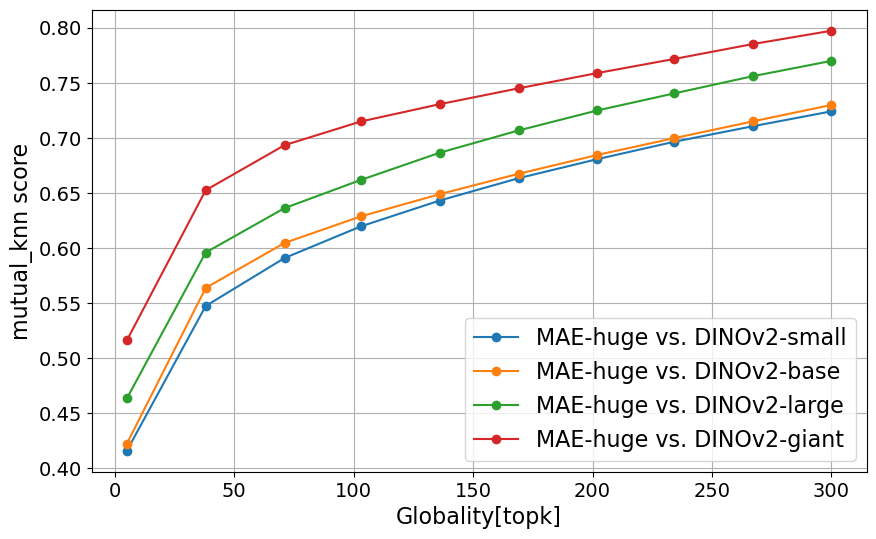

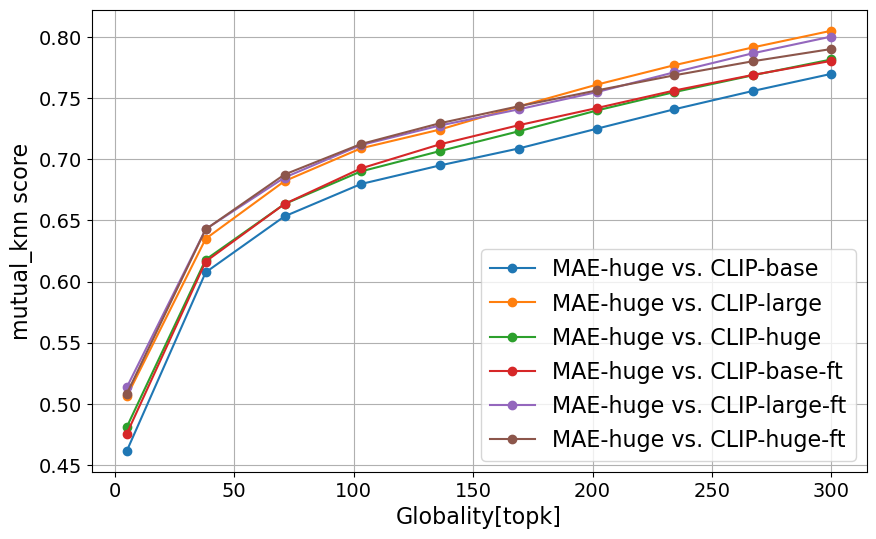

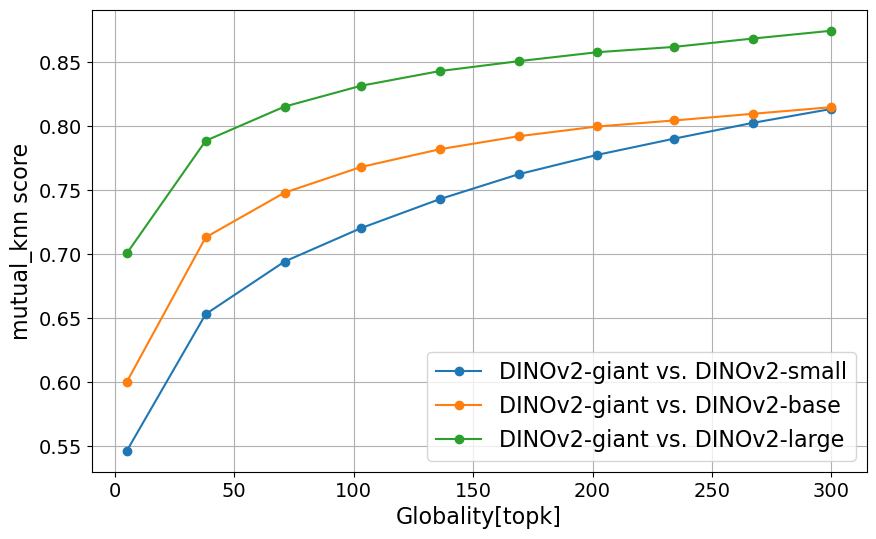

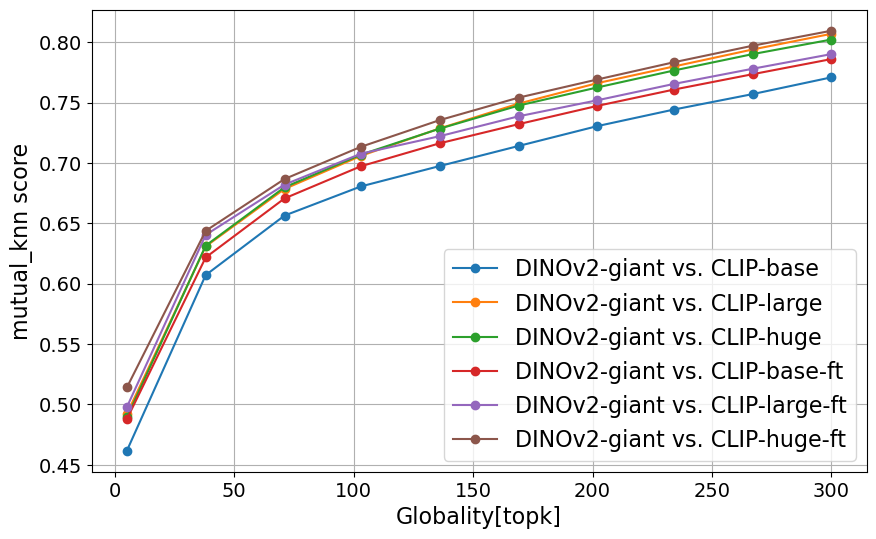

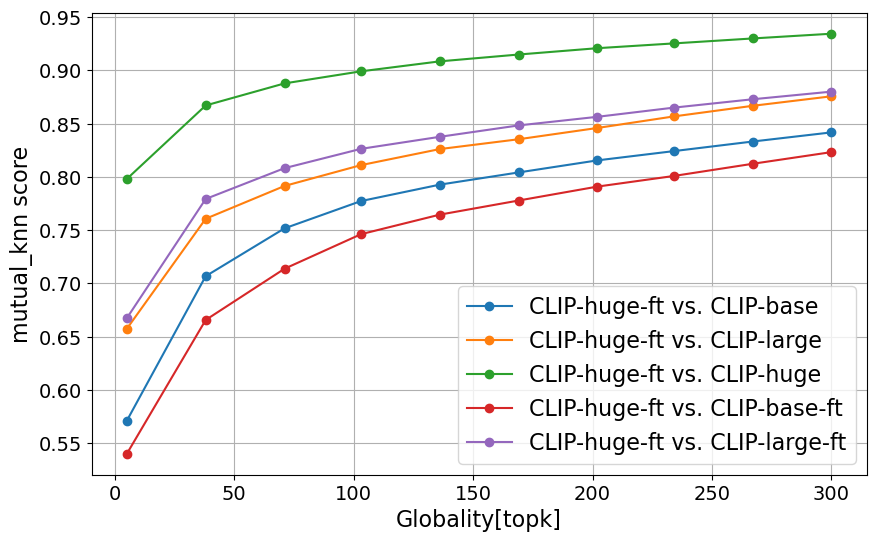

In [27]:
families_x = vision_model_families if sim_params['modality_x'] == "vision" else language_model_families
families_y = vision_model_families if sim_params['modality_y'] == "vision" else language_model_families

# plot similarity vs. globality for each unique family pair
family_pairs = []
for fam_x in families_x:
    for fam_y in families_y:
        if (fam_y, fam_x) in family_pairs:
            continue
        family_pairs.append((fam_x, fam_y))
        plot_similarity_globality(
            data, model_names_x, model_names_y,
            fam_x, fam_y,
            figure_path,
            fontsize=fontsize
        )

In [29]:
[m for m in model_names_x if 'mae' in m]
model_names_map.get('vit_huge_patch14_224.mae', 0)

'MAE-huge'